# Использование энкодеров

Сравнение результатов: показатели ошибок

Модели: линейная регрессия, градиентный бустинг

# Готовим датасет

In [ ]:
import pandas as pd

In [ ]:
! kaggle datasets download mfarhaannazirkhan/heart-dataset -f cleaned_merged_heart_dataset.csv

Dataset URL: https://www.kaggle.com/datasets/mfarhaannazirkhan/heart-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/70.1k [00:00<?, ?B/s]
100% 70.1k/70.1k [00:00<00:00, 949kB/s]


In [ ]:
data = pd.read_csv('cleaned_merged_heart_dataset.csv')

- age: Age of the patient (Numeric).
- sex: Gender of the patient. Values: 1 = male, 0 = female.
- cp: Chest pain type. Values: 0 = Typical angina, 1 = Atypical angina, 2 = Non-anginal pain, 3 = Asymptomatic.
- trestbps: Resting Blood Pressure (in mm Hg) (Numeric).
- chol: Serum Cholesterol level (in mg/dl) (Numeric).
- fbs: Fasting blood sugar > 120 mg/dl. Values: 1 = true, 0 = false.
- restecg: Resting electrocardiographic results. Values: 0 = Normal, 1 = ST-T wave abnormality, 2 = Left ventricular hypertrophy.
- thalach: Maximum heart rate achieved (Numeric).
- exang: Exercise-induced angina. Values: 1 = yes, 0 = no.
- oldpeak: ST depression induced by exercise relative to rest (Numeric).
- slope: Slope of the peak exercise ST segment. Values: 0 = Upsloping, 1 = Flat, 2 = Downsloping.
- ca: Number of major vessels (0-3) colored by fluoroscopy. Values: 0, 1, 2, 3.
- thal: Thalassemia types. Values: 1 = Normal, 2 = Fixed defect, 3 = Reversible defect.
- target: Outcome variable (heart attack risk). Values: 1 = more chance of heart attack, 0 = less chance of heart attack.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1888 entries, 0 to 1887
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1888 non-null   int64  
 1   sex       1888 non-null   int64  
 2   cp        1888 non-null   int64  
 3   trestbps  1888 non-null   int64  
 4   chol      1888 non-null   int64  
 5   fbs       1888 non-null   int64  
 6   restecg   1888 non-null   int64  
 7   thalachh  1888 non-null   int64  
 8   exang     1888 non-null   int64  
 9   oldpeak   1888 non-null   float64
 10  slope     1888 non-null   int64  
 11  ca        1888 non-null   int64  
 12  thal      1888 non-null   int64  
 13  target    1888 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 206.6 KB


5 - количественных:
- age
- trestbps
- chol
- thalachh
- oldpeak

8 - категориальных:
- sex
- cp
- fbs
- restecg
- exang
- slope
- ca
- thal

1 - таргет

In [ ]:
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1883,60,1,0,140,207,0,0,138,1,1.9,2,1,3,0
1884,46,1,0,140,311,0,1,120,1,1.8,1,2,3,0
1885,59,1,3,134,204,0,1,162,0,0.8,2,2,2,0
1886,54,1,1,154,232,0,0,164,0,0.0,2,1,2,0




---



**Делим на подвыборки:**

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    data.drop(columns='target'), data['target'], test_size=0.2, random_state=23
)

In [ ]:
X_train_num = X_train.drop(columns=[
    'sex', 'cp', 'fbs', 'restecg',
    'exang', 'slope', 'ca', 'thal'
])
X_test_num = X_test.drop(columns=[
    'sex', 'cp', 'fbs', 'restecg',
    'exang', 'slope', 'ca', 'thal'
])


X_train_cat = X_train.drop(columns=[
    'age', 'trestbps', 'chol',
    'thalachh', 'oldpeak'
])
X_test_cat = X_test.drop(columns=[
    'age', 'trestbps', 'chol',
    'thalachh', 'oldpeak'
])



---



**Для оценки результатов:**

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

In [ ]:
def get_metrics(y_true, y_pred):
  return {
      'r2': r2_score(y_true, y_pred),
      'mae': mean_absolute_error(y_true, y_pred),
      'rmse': root_mean_squared_error(y_true, y_pred)
  }

r2 -  функция оценки регрессии (коэффициент детерминации). -> 1.0

mae - потеря средней абсолютной ошибки регрессии. -> 0.0

rmse - потеря регрессии при среднеквадратичной ошибке. -> 0.0

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [ ]:
def get_metrics(y_true, y_pred):
  return {
      'acc': accuracy_score(y_true, y_pred),
      'prec': precision_score(y_true, y_pred),
      'recall': recall_score(y_true, y_pred)
  }

In [ ]:
final_results = pd.DataFrame()



---

---





# Линейная регрессия (numeric)

In [ ]:
from sklearn.linear_model import LinearRegression as LR

In [ ]:
lr_num = LR().fit(X_train_num, Y_train)
lr_num_results = get_metrics(Y_test, lr_num.predict(X_test_num))
final_results['LinearRegression_numeric'] = lr_num_results
lr_num_results

{'r2': 0.12217035831113465,
 'mae': 0.43413983494075165,
 'rmse': 0.46793137805763657}

In [ ]:
from sklearn.linear_model import LogisticRegression as LR

In [ ]:
lr_num = LR().fit(X_train_num, Y_train)
lr_num_results = get_metrics(Y_test, lr_num.predict(X_test_num))
final_results['LogisticRegression_numeric'] = lr_num_results
lr_num_results

{'acc': 0.6613756613756614, 'prec': 0.65625, 'recall': 0.7424242424242424}

# Градиентный бустинг (numeric)

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor as GBR

In [ ]:
gbr_num = GBR().fit(X_train_num, Y_train)
gbr_num_results = get_metrics(Y_test, gbr_num.predict(X_test_num))
final_results['GBR_numeric'] = gbr_num_results
gbr_num_results

Стало немного лучше, но не весомо.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier as GBR

In [ ]:
gbr_num = GBR().fit(X_train_num, Y_train)
gbr_num_results = get_metrics(Y_test, gbr_num.predict(X_test_num))
final_results['GBR_numeric'] = gbr_num_results
gbr_num_results

{'acc': 0.791005291005291,
 'prec': 0.7819905213270142,
 'recall': 0.8333333333333334}

# Энкодинги

## One Hot

Как get_dummies()

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
one_hot_encoder = OneHotEncoder(sparse_output=False)

In [ ]:
one_hot_encoder.fit(
    data[[
        'sex', 'cp', 'fbs', 'restecg',
        'exang', 'slope', 'ca', 'thal'
    ]]
)

OneHotEncoder(sparse_output=False)

In [ ]:
one_hot_encoder.categories_

[array([0, 1]),
 array([0, 1, 2, 3, 4]),
 array([0, 1]),
 array([0, 1, 2]),
 array([0, 1]),
 array([0, 1, 2, 3]),
 array([0, 1, 2, 3, 4]),
 array([0, 1, 2, 3, 6, 7])]

In [ ]:
# названия колонок
ctgr = []
ct = one_hot_encoder.categories_
clmn = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
for i in range(len(ct)):
  for n in ct[i]:
    ctgr.append(clmn[i]+'_'+str(n))

In [ ]:
# категориальные
X_train_one_h_df = pd.DataFrame(
    one_hot_encoder.transform(X_train_cat),
    columns=ctgr
)

X_train_one_h_df.head(3)

,sex_0,sex_1,cp_0,cp_1,cp_2,cp_3,cp_4,fbs_0,fbs_1,restecg_0,...,ca_1,ca_2,ca_3,ca_4,thal_0,thal_1,thal_2,thal_3,thal_6,thal_7
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
X_test_one_h_df = pd.DataFrame(
    one_hot_encoder.transform(X_test_cat),
    columns=ctgr
)

X_test_one_h_df.head(3)

,sex_0,sex_1,cp_0,cp_1,cp_2,cp_3,cp_4,fbs_0,fbs_1,restecg_0,...,ca_1,ca_2,ca_3,ca_4,thal_0,thal_1,thal_2,thal_3,thal_6,thal_7
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
df = X_train_num.reset_index().drop(columns='index')
X_train_os = pd.concat([X_train_one_h_df, df], axis=1)

df = X_test_num.reset_index().drop(columns='index')
X_test_os = pd.concat([X_test_one_h_df, df], axis=1)

**Модели:**

In [ ]:
one_shot_lr = LR().fit(X_train_os, Y_train)
one_shot_lr_results = get_metrics(Y_test, one_shot_lr.predict(X_test_os))
final_results['one_shot_LinearRegression'] = one_shot_lr_results
one_shot_lr_results

{'r2': 0.4202390475852601,
 'mae': 0.29802669502461315,
 'rmse': 0.3802782868272235}

In [ ]:
one_shot_gbr = GBR().fit(X_train_os, Y_train)
one_shot_gbr_results = get_metrics(
    Y_test, one_shot_gbr.predict(X_test_os)
)
final_results['one_shot_GBR'] = one_shot_gbr_results
one_shot_gbr_results

{'r2': 0.626077530003021,
 'mae': 0.21698637506646043,
 'rmse': 0.30539915407529217}

In [ ]:
one_shot_lr = LR().fit(X_train_os, Y_train)
one_shot_lr_results = get_metrics(Y_test, one_shot_lr.predict(X_test_os))
final_results['one_shot_LogisticRegression'] = one_shot_lr_results
one_shot_lr_results

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'acc': 0.8068783068783069,
 'prec': 0.8140703517587939,
 'recall': 0.8181818181818182}

In [ ]:
one_shot_gbr = GBR().fit(X_train_os, Y_train)
one_shot_gbr_results = get_metrics(
    Y_test, one_shot_gbr.predict(X_test_os)
)
final_results['one_shot_GBR'] = one_shot_gbr_results
one_shot_gbr_results

{'acc': 0.8915343915343915,
 'prec': 0.8829268292682927,
 'recall': 0.9141414141414141}

## LabelEncoder

In [ ]:
from sklearn.preprocessing import LabelEncoder as LE

In [ ]:
X_train_le_df = pd.DataFrame()
X_test_le_df = pd.DataFrame()

In [ ]:
my_categories = [
        'sex', 'cp', 'fbs', 'restecg',
        'exang', 'slope', 'ca', 'thal'
    ]

for i in my_categories:
  le_x = LE().fit(data[i])
  X_train_le_df[i] = le_x.transform(X_train_cat[i])
  X_test_le_df[i] = le_x.transform(X_test_cat[i])

In [ ]:
X_train_le_df.head(3)

,sex,cp,fbs,restecg,exang,slope,ca,thal
0,1,1,0,1,0,2,0,2
1,0,1,0,1,0,2,1,2
2,0,1,1,0,1,2,1,2


In [ ]:
data['thal'].unique(), X_train_le_df['thal'].unique()

(array([1, 2, 3, 0, 7, 6]), array([2, 3, 1, 5, 0, 4]))

In [ ]:
df = X_train_num.reset_index().drop(columns='index')
X_train_le = pd.concat([X_train_le_df, df], axis=1)

df = X_test_num.reset_index().drop(columns='index')
X_test_le = pd.concat([X_test_le_df, df], axis=1)

**Модели:**

In [ ]:
lbl_encoder_lr = LR().fit(X_train_le, Y_train)
lbl_encoder_lr_results = get_metrics(
    Y_test, lbl_encoder_lr.predict(X_test_le)
)
final_results['label_enc_LinearRegression'] = lbl_encoder_lr_results
lbl_encoder_lr_results

{'r2': 0.32784502723315456,
 'mae': 0.3468090213760559,
 'rmse': 0.40946025809315917}

In [ ]:
lbl_encoder_gbr = GBR().fit(X_train_le, Y_train)
lbl_encoder_gbr_results = get_metrics(
    Y_test, lbl_encoder_gbr.predict(X_test_le)
)
final_results['label_enc_GBR'] = lbl_encoder_gbr_results
lbl_encoder_gbr_results

{'r2': 0.6109249699999146,
 'mae': 0.22408467584923608,
 'rmse': 0.3115255903197321}

In [ ]:
lbl_encoder_lr = LR().fit(X_train_le, Y_train)
lbl_encoder_lr_results = get_metrics(
    Y_test, lbl_encoder_lr.predict(X_test_le)
)
final_results['label_enc_LogisticRegression'] = lbl_encoder_lr_results
lbl_encoder_lr_results

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'acc': 0.7698412698412699,
 'prec': 0.7466666666666667,
 'recall': 0.8484848484848485}

In [ ]:
lbl_encoder_gbr = GBR().fit(X_train_le, Y_train)
lbl_encoder_gbr_results = get_metrics(
    Y_test, lbl_encoder_gbr.predict(X_test_le)
)
final_results['label_enc_GBR'] = lbl_encoder_gbr_results
lbl_encoder_gbr_results

{'acc': 0.8835978835978836,
 'prec': 0.8774509803921569,
 'recall': 0.9040404040404041}

## TargetEncoder

In [ ]:
from sklearn.preprocessing import TargetEncoder as TE

In [ ]:
te_encoder = TE(smooth="auto")
te_encoder.fit(
    data[[
        'sex', 'cp', 'fbs', 'restecg',
        'exang', 'slope', 'ca', 'thal'
    ]],
    data['target']
)

TargetEncoder()

In [ ]:
X_train_te_df = pd.DataFrame(
    data=te_encoder.transform(X_train_cat),
    columns=[
        'sex', 'cp', 'fbs', 'restecg',
        'exang', 'slope', 'ca', 'thal'
    ]
)

X_test_te_df = pd.DataFrame(
    data=te_encoder.transform(X_test_cat),
    columns=[
        'sex', 'cp', 'fbs', 'restecg',
        'exang', 'slope', 'ca', 'thal'
    ]
)

In [ ]:
df = X_train_num.reset_index().drop(columns='index')
X_train_te = pd.concat([X_train_te_df, df], axis=1)

df = X_test_num.reset_index().drop(columns='index')
X_test_te = pd.concat([X_test_te_df, df], axis=1)

**Модели:**

In [ ]:
te_encoder_lr = LR().fit(X_train_te, Y_train)
te_encoder_lr_results = get_metrics(
    Y_test, te_encoder_lr.predict(X_test_te)
)
final_results['target_enc_LinearRegression'] = te_encoder_lr_results
te_encoder_lr_results

{'r2': 0.42500053203750243, 'mae': 0.295746585342034, 'rmse': 0.37871348480535}

In [ ]:
te_encoder_gbr = GBR().fit(X_train_te, Y_train)
te_encoder_gbr_results = get_metrics(
    Y_test, te_encoder_gbr.predict(X_test_te)
)
final_results['target_enc_GBR'] = te_encoder_gbr_results
te_encoder_gbr_results

{'r2': 0.6012739091077137,
 'mae': 0.21944276110707814,
 'rmse': 0.31536564100128767}

In [ ]:
te_encoder_lr = LR().fit(X_train_te, Y_train)
te_encoder_lr_results = get_metrics(
    Y_test, te_encoder_lr.predict(X_test_te)
)
final_results['target_enc_LogisticRegression'] = te_encoder_lr_results
te_encoder_lr_results

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'acc': 0.791005291005291,
 'prec': 0.7931034482758621,
 'recall': 0.8131313131313131}

In [ ]:
te_encoder_gbr = GBR().fit(X_train_te, Y_train)
te_encoder_gbr_results = get_metrics(
    Y_test, te_encoder_gbr.predict(X_test_te)
)
final_results['target_enc_GBR'] = te_encoder_gbr_results
te_encoder_gbr_results

{'acc': 0.8835978835978836,
 'prec': 0.8701923076923077,
 'recall': 0.9141414141414141}

# CatBoost

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 6.1 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor as CBR

In [ ]:
from catboost import CatBoostClassifier as CBR

In [ ]:
cbr = CBR().fit(X_train, Y_train)

Learning rate set to 0.012284
0:	learn: 0.6830806	total: 53.7ms	remaining: 53.7s
1:	learn: 0.6702800	total: 57.4ms	remaining: 28.7s
2:	learn: 0.6603033	total: 66.3ms	remaining: 22s
3:	learn: 0.6497849	total: 70.6ms	remaining: 17.6s
4:	learn: 0.6378828	total: 75.1ms	remaining: 15s
5:	learn: 0.6287452	total: 79.5ms	remaining: 13.2s
6:	learn: 0.6189307	total: 92.8ms	remaining: 13.2s
7:	learn: 0.6079189	total: 97.1ms	remaining: 12s
8:	learn: 0.5984183	total: 101ms	remaining: 11.2s
9:	learn: 0.5899084	total: 109ms	remaining: 10.8s
10:	learn: 0.5799004	total: 114ms	remaining: 10.2s
11:	learn: 0.5706506	total: 119ms	remaining: 9.76s
12:	learn: 0.5620795	total: 124ms	remaining: 9.38s
13:	learn: 0.5539955	total: 131ms	remaining: 9.21s
14:	learn: 0.5471419	total: 142ms	remaining: 9.3s
15:	learn: 0.5397462	total: 151ms	remaining: 9.27s
16:	learn: 0.5337489	total: 154ms	remaining: 8.88s
17:	learn: 0.5274589	total: 158ms	remaining: 8.65s
18:	learn: 0.5189312	total: 163ms	remaining: 8.44s
19:	learn:

In [ ]:
cbr_results = get_metrics(Y_test, cbr.predict(X_test))
final_results['CatBoostRegressor'] = cbr_results
cbr_results

{'r2': 0.8557490629213387,
 'mae': 0.0800911821347409,
 'rmse': 0.18968647648692397}

In [ ]:
cbr_results = get_metrics(Y_test, cbr.predict(X_test))
final_results['CatBoostClassifier'] = cbr_results
cbr_results

{'acc': 0.9576719576719577, 'prec': 0.955, 'recall': 0.9646464646464646}

# Результаты

In [ ]:
final_results

,LogisticRegression_numeric,GBR_numeric,one_shot_LogisticRegression,one_shot_GBR,label_enc_LogisticRegression,label_enc_GBR,target_enc_LogisticRegression,target_enc_GBR,CatBoostClassifier
acc,0.661376,0.791005,0.806878,0.891534,0.769841,0.883598,0.791005,0.883598,0.957672
prec,0.656250,0.781991,0.814070,0.882927,0.746667,0.877451,0.793103,0.870192,0.955000
recall,0.742424,0.833333,0.818182,0.914141,0.848485,0.904040,0.813131,0.914141,0.964646


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

<ipython-input-50-703b995c2bd2>:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i-0.12, 0.03, str("%.3f" % tr[n]))
<ipython-input-50-703b995c2bd2>:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i-0.12, 0.03, str("%.3f" % ts[n]), color='w')
<ipython-input-50-703b995c2bd2>:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i-0.12, 0.03, str("%.3f" % cr[n]), color='w')


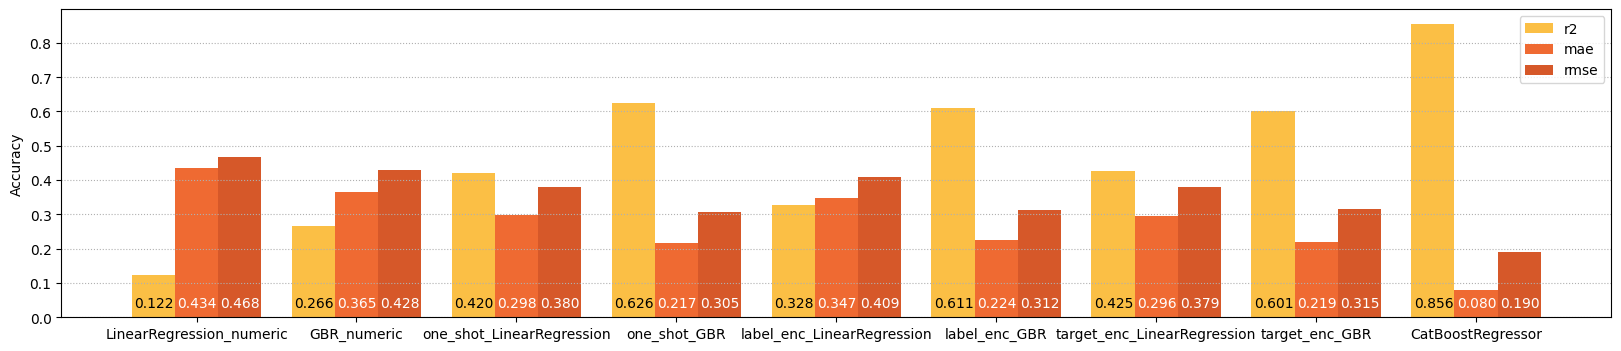

In [ ]:
tr = final_results.iloc[0]
ts = final_results.iloc[1]
cr = final_results.iloc[2]

plt.figure(figsize=(20, 4))
barWidth = 0.27

br1 = np.arange(len(tr))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]

plt.bar(br1, tr, color ='#fbbf45', width = barWidth, label ='r2')
plt.bar(br2, ts, color ='#ef6a32', width = barWidth, label ='mae')
plt.bar(br3, cr, color ='#d65829', width = barWidth, label ='rmse')

n = 0
for i in br1:
    plt.text(i-0.12, 0.03, str("%.3f" % tr[n]))
    n += 1

n = 0
for i in br2:
    plt.text(i-0.12, 0.03, str("%.3f" % ts[n]), color='w')
    n += 1

n = 0
for i in br3:
    plt.text(i-0.12, 0.03, str("%.3f" % cr[n]), color='w')
    n += 1

plt.ylabel('Accuracy')
plt.xticks([r + barWidth for r in range(len(tr))], final_results.columns)
#plt.yticks(np.arange(0, 1.05, 0.05))

plt.legend(loc='best')
plt.grid(True, axis = 'y', linestyle=':')
plt.show()



---



---



**Выводы:**
- если обучаем только на вещественных признаках, то выбираем градиентный бустинг
- при каждой кодировке градиентный бустинг лучше
- лучший результат при использовании кодировки = градиентный бустинг в связке с OneHot кодировкой

по графику видно, что лучшие результаты показал CatBoost

<ipython-input-54-377298fbab10>:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i-0.12, 0.03, str("%.3f" % tr[n]))
<ipython-input-54-377298fbab10>:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i-0.12, 0.03, str("%.3f" % ts[n]), color='w')
<ipython-input-54-377298fbab10>:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i-0.12, 0.03, str("%.3f" % cr[n]), color='w')


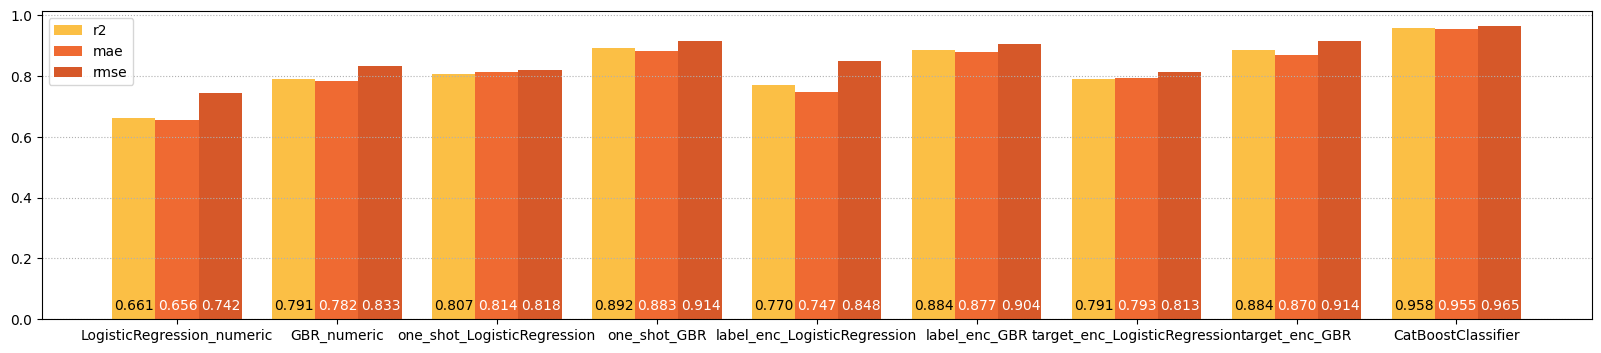

In [ ]:
tr = final_results.iloc[0]
ts = final_results.iloc[1]
cr = final_results.iloc[2]

plt.figure(figsize=(20, 4))
barWidth = 0.27

br1 = np.arange(len(tr))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]

plt.bar(br1, tr, color ='#fbbf45', width = barWidth, label ='r2')
plt.bar(br2, ts, color ='#ef6a32', width = barWidth, label ='mae')
plt.bar(br3, cr, color ='#d65829', width = barWidth, label ='rmse')

n = 0
for i in br1:
    plt.text(i-0.12, 0.03, str("%.3f" % tr[n]))
    n += 1

n = 0
for i in br2:
    plt.text(i-0.12, 0.03, str("%.3f" % ts[n]), color='w')
    n += 1

n = 0
for i in br3:
    plt.text(i-0.12, 0.03, str("%.3f" % cr[n]), color='w')
    n += 1

#plt.ylabel('Accuracy')
plt.xticks([r + barWidth for r in range(len(tr))], final_results.columns)
#plt.yticks(np.arange(0, 1.05, 0.05))

plt.legend(loc='best')
plt.grid(True, axis = 'y', linestyle=':')
plt.show()